In [1]:
import os
import glob
import json
import yaml
import numpy as np
import torch
import argparse

import sys
from pathlib import Path
__abs_path__ = str(Path.cwd().parents[0].absolute())
__utils_path__ = f'{__abs_path__}/utils'

for __util_path__ in [__abs_path__, __utils_path__]:
    if not __util_path__ in sys.path:
        sys.path+=[__util_path__]

from eval_CBD import Options, Trainer

import trimesh
from utils import ICT_face_model, YamlArgParser
from utils.matplotlib_rnd import (
    render_mesh_diff,
    plot_image_array
)
import igl

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [9]:
config = f'{__abs_path__}/config/train_CBD.yml'
opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)

opts.dec_type = 'disp'

## version 8
# opts.ckpt = '../ckpts_CBD/2025-09-29-14-48-17-NGBCv8' ## ------> 1 1 
# opts.ckpt = '../ckpts_CBD/2025-09-29-14-48-19-NGBCv8' ## ------> 1 1 none
# opts.ckpt = '../ckpts_CBD/2025-10-05-22-59-45-NGBCv8' ## ------> 1 0

## version 5
# opts.ckpt = '../ckpts_CBD/2025-09-27-08-05-11-NGBCv5' ## ------> 1 1
# opts.ckpt = '../ckpts_CBD/2025-09-27-07-44-28-NGBCv5' ## ------> 2 1
# opts.ckpt = '../ckpts_CBD/2025-09-28-15-27-33-NGBCv5' ## ------> 2 0 
opts.ckpt = '../ckpts_CBD/2025-09-26-10-16-32-NGBCv5' ## ------> 1 1 
# opts.ckpt = '../ckpts_CBD/2025-09-27-12-04-29-NGBCv5' ## ------> 1 0
# opts.ckpt = '../ckpts_CBD/2025-10-09-01-42-26-NGBCv5' ## ------> 1 1 (128? -> 512)
# opts.ckpt = '../ckpts_CBD/2025-10-03-22-40-03-NGBCv5' ## ------> 1 1 relu (softpou)

opts.in_type=1
opts.out_type=1

opts.num_cage_v=512
# opts.num_cage_v=128

opts.version=5

opts.last_activation='relu'
# opts.last_activation='none'

opts.no_pou=False

trainer = Trainer(opts)

shape model not used!, use_shp_recon set to False
Loading... ../ckpts_CBD/2025-09-26-10-16-32-NGBCv5/model_best.pth


# Retarget single frame

(3515, 3)
(11248, 3)


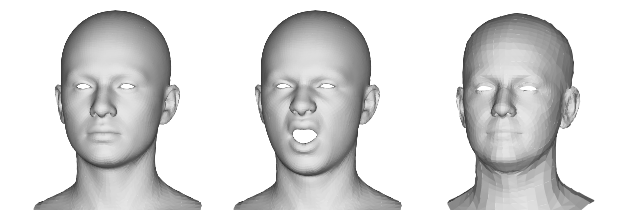

In [3]:
## full head
ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()

## flame
flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/flame_final_transformed.obj', process=False, maintain_order=True)
flame_tri.vertices=flame_tri.vertices+np.array([0,0.1,0])
# flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/biwi_M5.obj', process=False, maintain_order=True)
# flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/biwi_M5_deci.obj', process=False, maintain_order=True)
print(flame_tri.vertices.shape)

## ICT random expression
# bs_coeff = np.eye(53)[26]
bs_coeff = np.eye(53)[51] + np.eye(53)[52] + np.eye(53)[26] * 0.5
vertices = torch.from_numpy(ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff))
src_mesh = ict_tri
tgt_mesh = flame_tri


print(ict_tri.vertices.shape)

M_SCALE = 0.68
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE ]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces ]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [4]:
device=trainer.device
print(device)

sd_v = ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff).squeeze(0)
# print(sd_v.shape)
s_v_B_th = torch.from_numpy(ict_tri.vertices)[None].float().to(device)
s_n_B_th = torch.from_numpy(igl.per_vertex_normals(ict_tri.vertices, ict_tri.faces))[None].float().to(device)
sd_v_B_th = torch.from_numpy(sd_v)[None].float().to(device)
sd_n_B_th = torch.from_numpy(igl.per_vertex_normals(sd_v, ict_tri.faces))[None].float().to(device)
t_v_B_th = torch.from_numpy(tgt_mesh.vertices)[None].float().to(device)
t_n_B_th = torch.from_numpy(igl.per_vertex_normals(tgt_mesh.vertices, tgt_mesh.faces))[None].float().to(device)

pred_outputs, pred_source, exp_z_d, key_d, exp_z_s, key_s, key_weight = trainer.model.retarget(
    s_v_B_th, s_n_B_th, sd_v_B_th, sd_n_B_th, t_v_B_th, t_n_B_th, mesh_data=0, out_kw=True
)


cuda:0


 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


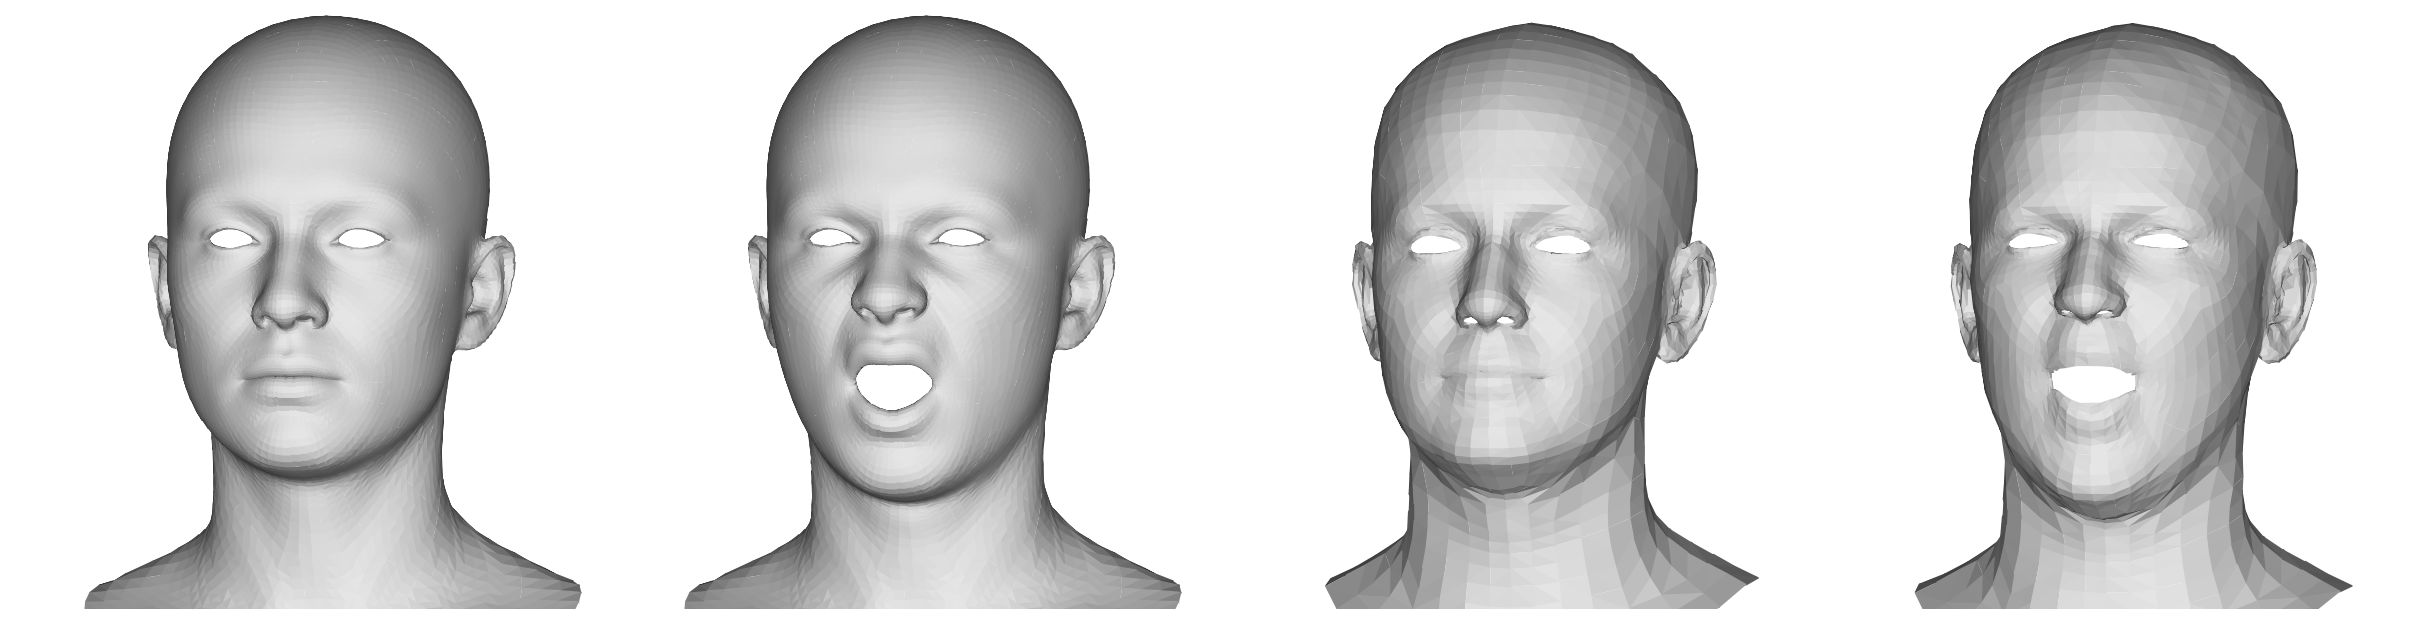

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


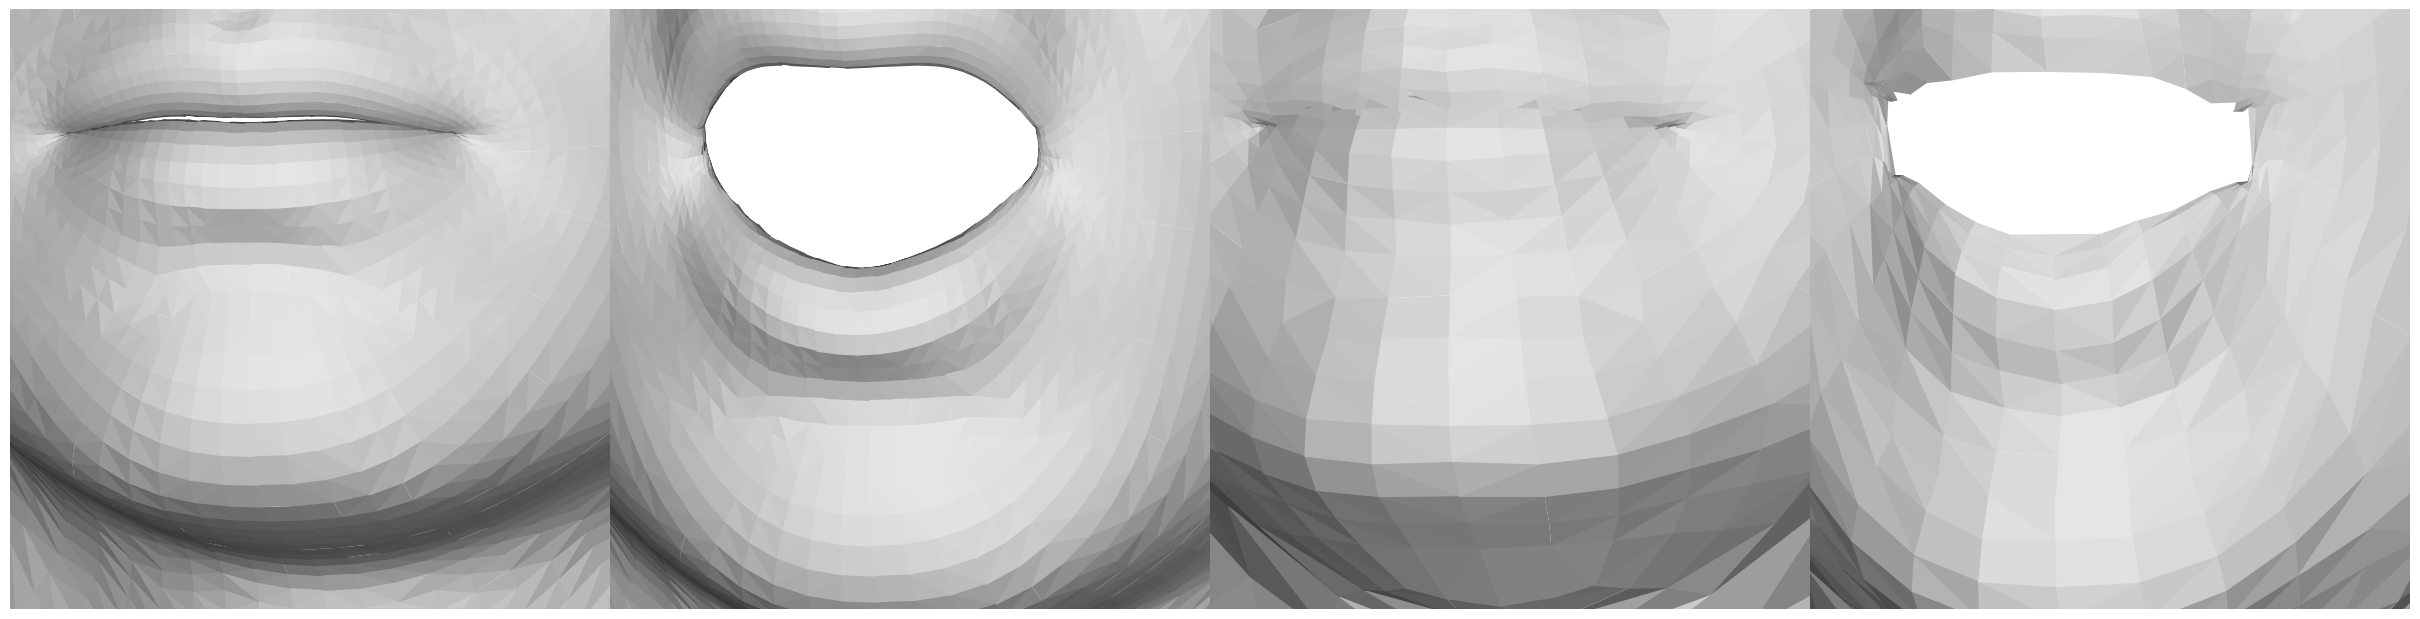

In [5]:
SIZE=6
M_SCALE=.82
SAVE=0

M_trns=np.array([0,0.,0])
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"NBC-retarget", save=SAVE
)

M_SCALE=1.7
M_trns=np.array([0.1, 1.6, 0])
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"NBC-retarget-zoom", save=SAVE
)

In [13]:
# SIZE=6
# M_SCALE=.82
# SAVE=0

# M_trns=np.array([0,0.,0])
# v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
# v_list = [v * M_SCALE + M_trns for v in v_list]
# f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

# print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
# plot_image_array(
#     v_list, f_list,
#     rot_list=[[0,-190,0]]*len(v_list), 
#     size=SIZE, bg_black=False, mode='shade', 
#     logdir=f"../_tmp", 
#     name=f"NBC-retarget", save=SAVE
# )

# M_SCALE=1.7
# M_trns=np.array([0.1, 1.9, 0])
# v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
# v_list = [v * M_SCALE + M_trns for v in v_list]
# f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

# print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
# plot_image_array(
#     v_list, f_list,
#     rot_list=[[0,-190,0]]*len(v_list), 
#     size=SIZE, bg_black=False, mode='shade', 
#     logdir=f"../_tmp", 
#     name=f"NBC-retarget-zoom", save=SAVE
# )

# Retarget animation

In [21]:
# load src neutral mesh
# load src animation
# load tgt neutral mesh

In [56]:
from dataloader_CBD import (
    EvalDataset,
    CBDDataBatch_eval,
    CBD_collate_wrapper_eval,
)
from functools import partial
from tqdm import tqdm

device='cuda:0'
SRC_SELECT=0
BS=16
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict']
selection = data_name_list[SRC_SELECT]

src_dataset = EvalDataset(data_name=selection, toggle=True) # if eve-s01
src_dataloader = torch.utils.data.DataLoader(
    src_dataset,
    batch_size=BS,
    collate_fn=partial(CBD_collate_wrapper_eval, device=device),
)
len_data = len(src_dataset)
print(f'max data length: {len_data}')


if selection=='voca':
    src_mesh = src_dataset.voca_mesh
elif selection=='biwi':
    src_mesh = src_dataset.biwi_mesh
elif selection=='mf_SEN':
    src_mesh = src_dataset.mf_SEN_mesh
elif selection=='coma':
    src_mesh = src_dataset.coma_mesh
elif selection=='mf_ROM':
    src_mesh = src_dataset.mf_ROM_mesh

src_mesh_list = [idname for idname in src_mesh.keys() if idname!='face']

voca data list exists: /source/sihun/NeuralFacialAnimation/utils/data/voca_vertex_data_test.txt
max data length: 9118


In [16]:
TGT_SELECT=-1
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM']
selection = data_name_list[TGT_SELECT]

tgt_dataset = EvalDataset(data_name=selection, toggle=True) # if eve-s01

if selection=='voca':
    tgt_mesh = tgt_dataset.voca_mesh
elif selection=='biwi':
    tgt_mesh = tgt_dataset.biwi_mesh
elif selection=='mf_SEN':
    tgt_mesh = tgt_dataset.mf_SEN_mesh
elif selection=='coma':
    tgt_mesh = tgt_dataset.coma_mesh
elif selection=='mf_ROM':
    tgt_mesh = tgt_dataset.mf_ROM_mesh

tgt_mesh_list = [idname for idname in tgt_mesh.keys() if idname!='face']

tgt_v = tgt_mesh[tgt_mesh_list[0]]
tgt_n = igl.per_vertex_normals(tgt_v, tgt_mesh['face'])
tgt_v_th = torch.tensor(tgt_v).float()[None].to(device)
tgt_n_th = torch.tensor(tgt_n).float()[None].to(device)

mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt


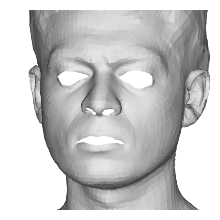

In [17]:
M_SCALE = 0.68
v_list=[ tgt_v ]
f_list=[ tgt_mesh['face'] ]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [58]:
file_name = 'coma-to-mf_ROM'
a2b_retarget_path = __abs_path__ + '/eval_CBD/'+opts.ckpt.split('/')[-1]+'/'+file_name
print(a2b_retarget_path)
os.makedirs(a2b_retarget_path, exist_ok=True) 

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-09-26-10-16-32-NGBCv5/coma-to-mf_ROM


In [61]:
FRAME = 0


# '/source/sihun/NeuralFacialAnimation/eval_CBD/2025-09-29-00-17-41-NGBCv5-eval'
pbar = tqdm(enumerate(src_dataloader), total=len_data, ncols=100)
for index, batch in pbar:
    if FRAME == index:
        with torch.no_grad():
            pred_outputs, pred_source, exp_z_d, key_d, exp_z_s, key_s, key_weight = trainer.model.retarget(
                batch.template, batch.template_normal, batch.vertices, batch.vertices_normal, tgt_v_th, tgt_n_th,
                mesh_data=batch.mesh_data, out_kw=True
            )

        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])
        break
    else:
        continue

  0%|                                                                      | 0/9118 [00:00<?, ?it/s]


     source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


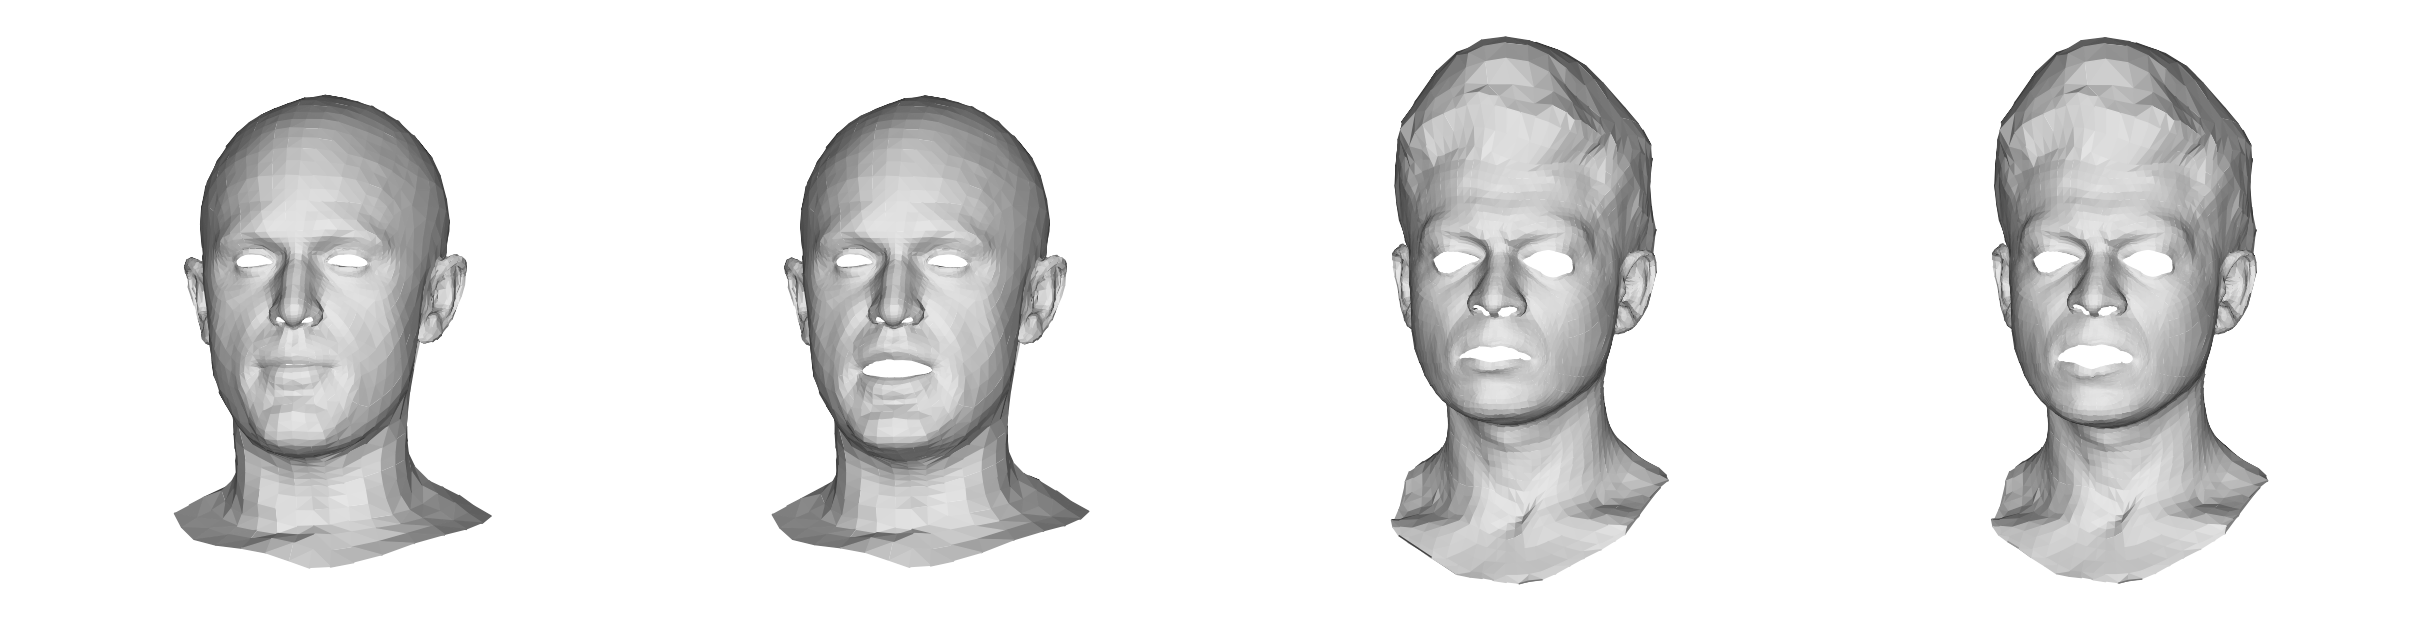

In [44]:
SIZE=6
M_SCALE=.7
SAVE=0

M_trns=np.array([0,0.,0])
v_list=[
    batch.template.detach().cpu().numpy()[0] * M_SCALE,
    batch.vertices.detach().cpu().numpy()[0] * M_SCALE,
    pred_source.detach().cpu().numpy()[0] * M_SCALE,
    pred_outputs.detach().cpu().numpy()[0] * M_SCALE,
]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ src_mesh['face'], src_mesh['face'], tgt_mesh['face'], tgt_mesh['face'] ]

print('     source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"A-to-B", save=SAVE
)